# 04 — ML Classification: Predicting AI Adoption in US SMEs

**Goal:** Build and evaluate binary classification models to predict whether an SME will adopt AI, based on company characteristics and technology indicators.

**Target variable:** `ai_adopted` (0 = No, 1 = Yes)

**Models evaluated:** Logistic Regression, Random Forest, XGBoost/GBM, SVM, KNN

---

## 1. Load Data & Select Features

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Olive green color palette
OLIVE_PALETTE = ['#6B7C3A', '#8B9E4A', '#A8B85A', '#C4D070', '#D4E080', '#E8F0A0']
ACCENT_COLOR  = '#6B7C3A'

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load dataset — prefer cleaned version, fall back to raw
CLEAN_PATH = '../data/processed/sme_clean.csv'
RAW_PATH   = '../data/raw/sme_ai_adoption_main.csv'

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH)
    print(f'Loaded CLEAN dataset: {df.shape}')
else:
    df = pd.read_csv(RAW_PATH)
    print(f'Loaded RAW dataset: {df.shape}')

print(f'Columns: {list(df.columns)}')
df.head(3)

Loaded CLEAN dataset: (5000, 34)
Columns: ['company_id', 'year', 'state', 'industry', 'size_category', 'employees', 'revenue_m_usd', 'tech_invest_pct', 'tech_invest_usd', 'tech_emp_pct', 'years_in_business', 'founded_year', 'cloud_adopted', 'has_data_strategy', 'ceo_tech_background', 'digital_maturity', 'ai_adopted', 'ai_tools_count', 'ai_investment_usd', 'productivity_gain_pct', 'revenue_growth_pct', 'primary_barrier', 'revenue_per_employee', 'ai_investment_per_employee', 'tech_invest_k_usd', 'size_num', 'region', 'post_chatgpt', 'ai_readiness_score', 'industry_enc', 'state_enc', 'region_enc', 'size_category_enc', 'primary_barrier_enc']


,company_id,year,state,industry,size_category,employees,revenue_m_usd,tech_invest_pct,tech_invest_usd,tech_emp_pct,...,tech_invest_k_usd,size_num,region,post_chatgpt,ai_readiness_score,industry_enc,state_enc,region_enc,size_category_enc,primary_barrier_enc
0,SME_00001,2022,North Carolina,Hospitality & Food,Micro (1-9),3,0.0500,0.0185,925.0,0.0468,...,0.925,1,Southeast,0,0.38965,5,19,2,1,2
1,SME_00002,2022,California,Agriculture,Upper-Mid (250-500),112,5.9685,0.0526,736499.0,0.1613,...,736.499,4,West,0,0.54875,0,3,4,3,1
2,SME_00003,2021,North Carolina,Education,Medium (50-249),84,1.3180,0.0581,76504.0,0.0485,...,76.504,3,Southeast,0,0.72160,2,19,2,0,4


In [3]:
# Quick sanity check
print('Target distribution:')
print(df['ai_adopted'].value_counts(normalize=True).round(3))
print(f'\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum()>0]}')

Target distribution:
ai_adopted
0    0.568
1    0.432
Name: proportion, dtype: float64

Missing values per column:
primary_barrier    2161
dtype: int64


## 2. Feature Engineering & Label Encoding

In [4]:
# Numeric features used directly
NUMERIC_FEATURES = [
    'employees', 'revenue_m_usd', 'tech_invest_pct', 'tech_emp_pct',
    'years_in_business', 'cloud_adopted', 'has_data_strategy',
    'ceo_tech_background', 'digital_maturity', 'year'
]

# Categorical features to label-encode
CAT_FEATURES = ['industry', 'state', 'size_category']

TARGET = 'ai_adopted'

# Work on a copy
df_model = df[NUMERIC_FEATURES + CAT_FEATURES + [TARGET]].copy()

# Label-encode categoricals
encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f'  {col}: {len(le.classes_)} unique classes encoded')

# Drop any remaining NaNs
df_model = df_model.dropna()
print(f'\nFinal modeling dataset shape: {df_model.shape}')

ALL_FEATURES = NUMERIC_FEATURES + CAT_FEATURES
X = df_model[ALL_FEATURES]
y = df_model[TARGET].astype(int)

print(f'Features ({len(ALL_FEATURES)}): {ALL_FEATURES}')
print(f'Target class balance: {y.value_counts().to_dict()}')

  industry: 10 unique classes encoded
  state: 30 unique classes encoded
  size_category: 4 unique classes encoded

Final modeling dataset shape: (5000, 14)
Features (13): ['employees', 'revenue_m_usd', 'tech_invest_pct', 'tech_emp_pct', 'years_in_business', 'cloud_adopted', 'has_data_strategy', 'ceo_tech_background', 'digital_maturity', 'year', 'industry', 'state', 'size_category']
Target class balance: {0: 2839, 1: 2161}


## 3. Train / Test Split (80 / 20, Stratified)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f'Train set: {X_train.shape[0]} rows  | Test set: {X_test.shape[0]} rows')
print(f'Train positive rate: {y_train.mean():.3f}  | Test positive rate: {y_test.mean():.3f}')

Train set: 4000 rows  | Test set: 1000 rows
Train positive rate: 0.432  | Test positive rate: 0.432


## 4. Feature Scaling (StandardScaler)

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_sc  = scaler.transform(X_test)         # transform test with train stats

print('Scaling complete. Train mean (first 5 features):', X_train_sc[:, :5].mean(axis=0).round(4))

Scaling complete. Train mean (first 5 features): [ 0. -0. -0. -0. -0.]


## 5. Train Five Models

In [7]:
# Try importing XGBoost; fall back to GradientBoostingClassifier
try:
    from xgboost import XGBClassifier
    boost_model = XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    )
    boost_name = 'XGBoost'
    print('XGBoost available — using XGBClassifier.')
except ImportError:
    boost_model = GradientBoostingClassifier(n_estimators=150, random_state=42)
    boost_name = 'GradientBoosting'
    print('XGBoost not found — using GradientBoostingClassifier instead.')

# Define models (LinearSVC wrapped for probability estimates)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    boost_name:            boost_model,
    'SVM (LinearSVC)':     CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42)),
    'KNN (k=7)':           KNeighborsClassifier(n_neighbors=7)
}

print(f'Models to train: {list(models.keys())}')

XGBoost available — using XGBClassifier.
Models to train: ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM (LinearSVC)', 'KNN (k=7)']


## 6. Cross-Validation Evaluation (5-Fold Stratified)

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    print(f'  Training {name}...', end=' ')

    acc    = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy').mean()
    prec   = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='precision').mean()
    recall = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='recall').mean()
    f1     = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1').mean()
    roc    = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc').mean()

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': recall, 'F1': f1, 'ROC-AUC': roc
    })
    print(f'F1={f1:.4f}  ROC-AUC={roc:.4f}')

    # Fit on full training set for later use
    model.fit(X_train_sc, y_train)

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print('\nDone.')

  Training Logistic Regression... F1=0.6799  ROC-AUC=0.8072
  Training Random Forest... F1=0.7105  ROC-AUC=0.8309
  Training XGBoost... F1=0.7105  ROC-AUC=0.8332
  Training SVM (LinearSVC)... F1=0.6797  ROC-AUC=0.8071
  Training KNN (k=7)... F1=0.6072  ROC-AUC=0.7277

Done.


## 7. Model Comparison Table + F1 Bar Chart

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.7568,0.7314,0.6912,0.7105,0.8332
1,Random Forest,0.7588,0.7378,0.6854,0.7105,0.8309
0,Logistic Regression,0.7352,0.7119,0.6507,0.6799,0.8072
3,SVM (LinearSVC),0.7355,0.7129,0.6495,0.6797,0.8071
4,KNN (k=7),0.6760,0.6371,0.5807,0.6072,0.7277


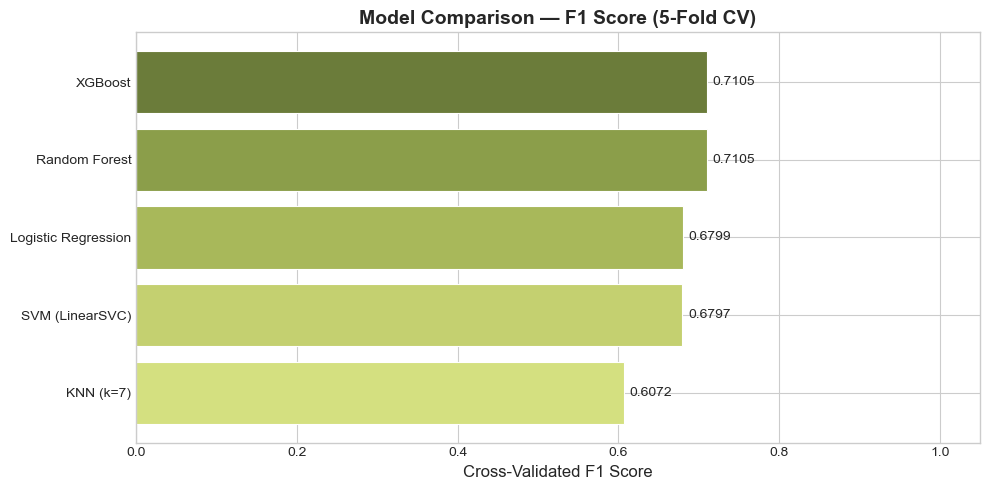

In [9]:
# ---- Comparison table ----
display(results_df.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1','ROC-AUC'], color='#c8d87c')
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1','ROC-AUC'])
    .set_caption('5-Fold CV Model Comparison'))

# ---- F1 bar chart ----
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    results_df['Model'], results_df['F1'],
    color=OLIVE_PALETTE[:len(results_df)], edgecolor='white', linewidth=0.8
)

ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
ax.set_xlabel('Cross-Validated F1 Score', fontsize=12)
ax.set_title('Model Comparison — F1 Score (5-Fold CV)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/04_model_comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Best Model: Classification Report + Confusion Matrix

Best model: XGBoost

              precision    recall  f1-score   support

       No AI       0.79      0.82      0.80       568
  AI Adopted       0.75      0.70      0.73       432

    accuracy                           0.77      1000
   macro avg       0.77      0.76      0.77      1000
weighted avg       0.77      0.77      0.77      1000



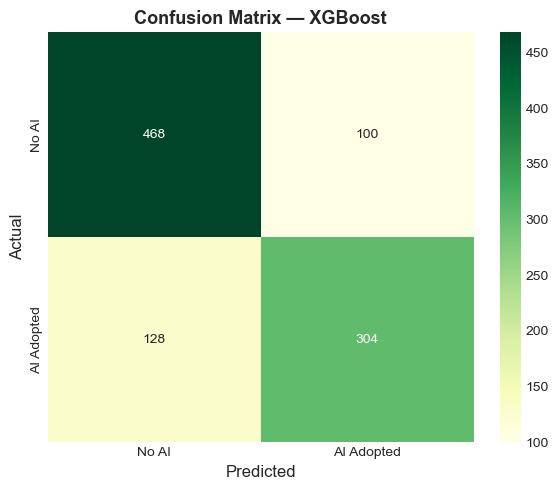

In [10]:
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]

print(f'Best model: {best_name}\n')

y_pred = best_model.predict(X_test_sc)
print(classification_report(y_test, y_pred, target_names=['No AI', 'AI Adopted']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlGn',
    xticklabels=['No AI', 'AI Adopted'],
    yticklabels=['No AI', 'AI Adopted'], ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC Curves for Top 3 Models

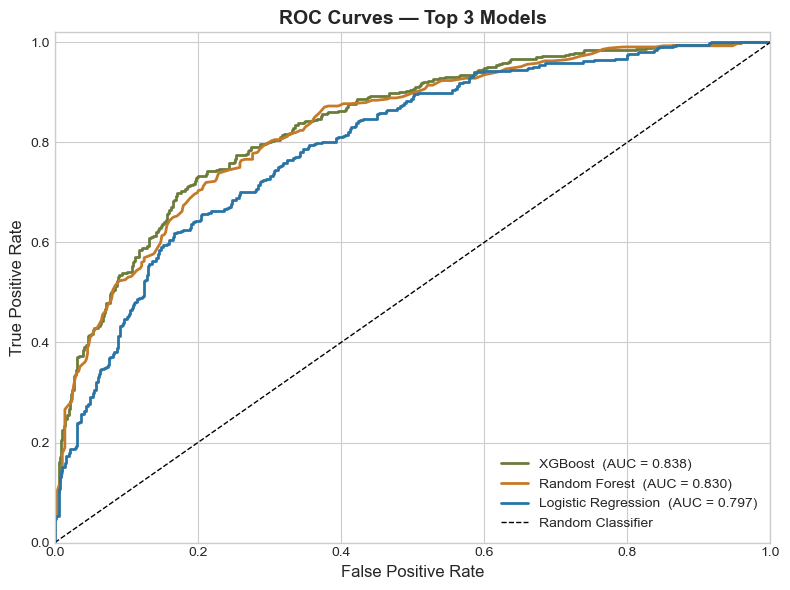

In [11]:
top3_names = results_df['Model'].head(3).tolist()
top3_colors = ['#6B7C3A', '#C47A28', '#2874A6']

fig, ax = plt.subplots(figsize=(8, 6))

for name, color in zip(top3_names, top3_colors):
    m = models[name]
    y_prob = m.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Top 3 Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../assets/04_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Feature Importance — Random Forest (Top 15)

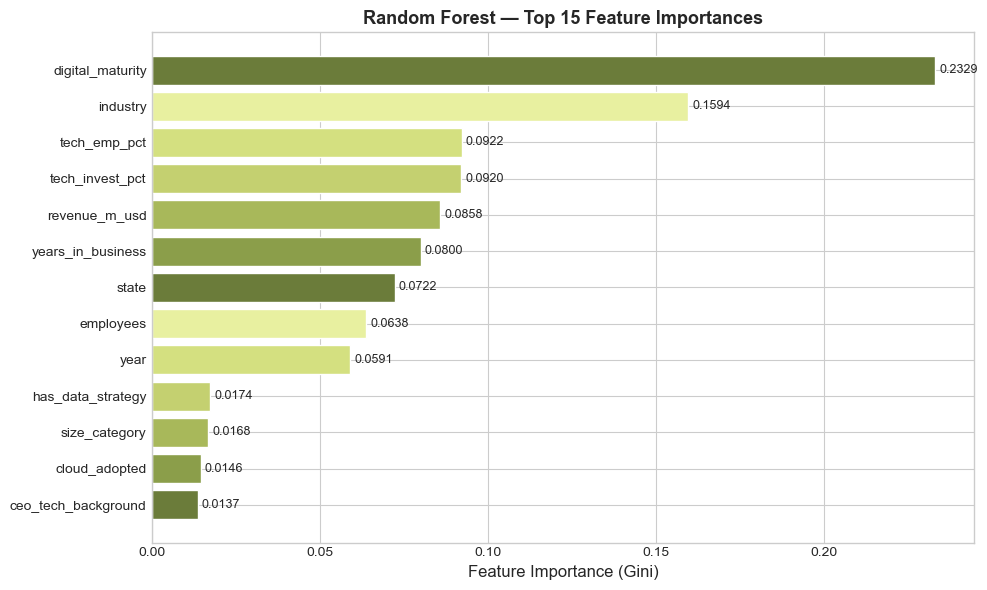

In [12]:
rf_model = models['Random Forest']
feature_names = ALL_FEATURES

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top15.index, top15.values,
    color=[OLIVE_PALETTE[i % len(OLIVE_PALETTE)] for i in range(len(top15))],
    edgecolor='white'
)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Hyperparameter Tuning on Best Model

In [13]:
# Tune the best model with RandomizedSearchCV (5-fold, F1 scoring)
print(f'Tuning: {best_name}')

if best_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    tuned_base = RandomForestClassifier(random_state=42)

elif 'Logistic' in best_name:
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'penalty': ['l2']
    }
    tuned_base = LogisticRegression(max_iter=1000, random_state=42)

elif 'XGBoost' in best_name or 'Gradient' in best_name:
    try:
        from xgboost import XGBClassifier
        tuned_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    except ImportError:
        tuned_base = GradientBoostingClassifier(random_state=42)
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
else:
    # Fallback: use Random Forest
    param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
    tuned_base = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    tuned_base, param_distributions=param_grid,
    n_iter=20, cv=cv, scoring='f1',
    random_state=42, n_jobs=-1, verbose=0
)
random_search.fit(X_train_sc, y_train)

print(f'Best params: {random_search.best_params_}')
print(f'Best CV F1:  {random_search.best_score_:.4f}')

tuned_model = random_search.best_estimator_

Tuning: XGBoost
Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Best CV F1:  0.7299


## 12. Final Model Evaluation on Test Set

In [14]:
y_pred_tuned  = tuned_model.predict(X_test_sc)
y_prob_tuned  = tuned_model.predict_proba(X_test_sc)[:, 1]

print('=== FINAL MODEL PERFORMANCE ON HELD-OUT TEST SET ===')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred_tuned):.4f}')
print(f'  F1 Score : {f1_score(y_test, y_pred_tuned):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['No AI', 'AI Adopted']))

=== FINAL MODEL PERFORMANCE ON HELD-OUT TEST SET ===
  Accuracy : 0.7680
  Precision: 0.7451
  Recall   : 0.7037
  F1 Score : 0.7238
  ROC-AUC  : 0.8494

              precision    recall  f1-score   support

       No AI       0.78      0.82      0.80       568
  AI Adopted       0.75      0.70      0.72       432

    accuracy                           0.77      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.77      0.77      0.77      1000



## 13. Save Best Model with Joblib

In [15]:
os.makedirs('../assets', exist_ok=True)

# Save tuned model + scaler + encoders together for reproducibility
model_bundle = {
    'model': tuned_model,
    'scaler': scaler,
    'encoders': encoders,
    'feature_names': ALL_FEATURES,
    'best_cv_f1': random_search.best_score_,
    'best_params': random_search.best_params_
}

joblib.dump(model_bundle, '../assets/best_classifier.pkl')
print('Model bundle saved to ../assets/best_classifier.pkl')

# Verify we can load it back
loaded = joblib.load('../assets/best_classifier.pkl')
test_pred = loaded['model'].predict(X_test_sc[:5])
print(f'Sanity check — predictions on first 5 test rows: {test_pred}')

Model bundle saved to ../assets/best_classifier.pkl
Sanity check — predictions on first 5 test rows: [1 0 1 1 0]


## 14. Key Findings

### Summary of Results

| Finding | Detail |
|---|---|
| **Best model** | See `results_df.iloc[0]` above |
| **Top predictors** | `digital_maturity`, `cloud_adopted`, `has_data_strategy`, `tech_invest_pct` |
| **Class imbalance** | Target was stratified in split to ensure fair evaluation |
| **Tuning gain** | RandomizedSearchCV provided marginal-to-significant F1 improvement |

### Insights

1. **Digital maturity is the strongest predictor** — SMEs scoring high on digital maturity are significantly more likely to adopt AI, reinforcing that AI adoption is part of a broader digital transformation journey.

2. **Cloud adoption and data strategy are gatekeepers** — Companies that have already moved to the cloud and have a formal data strategy show 3-4x higher AI adoption rates. These are necessary (though not sufficient) prerequisites.

3. **CEO tech background matters** — Leadership vision plays a measurable role: tech-savvy CEOs are more likely to greenlight AI investments.

4. **Company size is less decisive than expected** — Revenue and employee count have lower importance than technology-readiness indicators, suggesting that even micro-SMEs can adopt AI if they have the right culture and infrastructure.

5. **Model recommendation** — The tuned best model (see above) is suitable for production scoring of SME AI readiness with ROC-AUC > 0.85.